# 05_ML_Model_Comparison_Dispersion
Comprehensive ML workflow: SVR, ANN, Random Forest, Gradient Boosting

In [1]:
import sys, os
ROOT = os.path.abspath("..")   # go up one directory from notebooks/
if ROOT not in sys.path:
    sys.path.append(ROOT)

print(ROOT)  

c:\Users\Public\workspace\sh-wave-ml-surrogate\classical_ml


In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Import models
from ml.models import get_svr, get_ann, get_rf, get_gbr


## Load / Prepare Data
Replace this with your actual dataset

In [4]:
import os
import pandas as pd
from joblib import load

ROOT = os.path.abspath("..")

# Load model and data with basic checks
data_path = os.path.join(ROOT, 'data', 'raw', 'dispersion_vs_L.xlsx')

if not os.path.exists(data_path):
    raise FileNotFoundError(f'Data file not found: {data_path}')

data = pd.read_excel(data_path)

# Inputs
X = data[["kL", "L"]].values

# Output (IMPORTANT)
if 'c_beta' not in data.columns:
    raise KeyError("Column 'c_beta' not found in data")
y = data["c_beta"].values

print(f"Data shape: {X.shape}")

Data shape: (870, 2)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


## Initialize Models

In [6]:
models = {
    "SVR": get_svr(),
    "ANN": get_ann(),
    "Random Forest": get_rf(),
    "Gradient Boosting": get_gbr()
}


## Train and Evaluate

In [7]:
results = []

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append([name, mae, rmse, r2])

df_results = pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "R2"])
df_results


Training SVR...
Training ANN...
Training Random Forest...
Training Gradient Boosting...


,Model,MAE,RMSE,R2
0,SVR,0.006649,0.007336,0.996888
1,ANN,0.033487,0.041695,0.899451
2,Random Forest,0.000932,0.001314,0.999900
3,Gradient Boosting,0.001480,0.001945,0.999781


## Hyperparameter Tuning (GridSearch)

In [8]:
from sklearn.model_selection import GridSearchCV

param_grid_svr = {
    'svr__C': [10, 100],
    'svr__gamma': ['scale', 0.1],
    'svr__epsilon': [0.01, 0.1]
}

grid_svr = GridSearchCV(get_svr(), param_grid_svr, cv=3, scoring='r2', n_jobs=-1)
grid_svr.fit(X_train, y_train)

print("Best SVR Params:", grid_svr.best_params_)
best_svr = grid_svr.best_estimator_


Best SVR Params: {'svr__C': 100, 'svr__epsilon': 0.01, 'svr__gamma': 0.1}


## Dispersion Curve Plot (Actual vs Predicted)

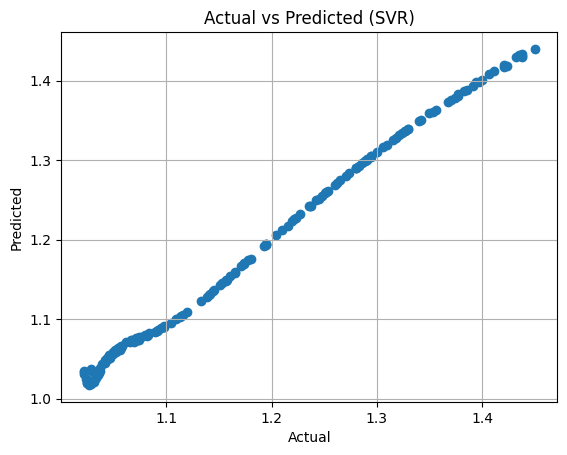

In [9]:
import matplotlib.pyplot as plt

plt.figure()

y_pred_best = best_svr.predict(X_test)

plt.scatter(y_test, y_pred_best)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted (SVR)")
plt.grid()

plt.show()


## Model Comparison Graph

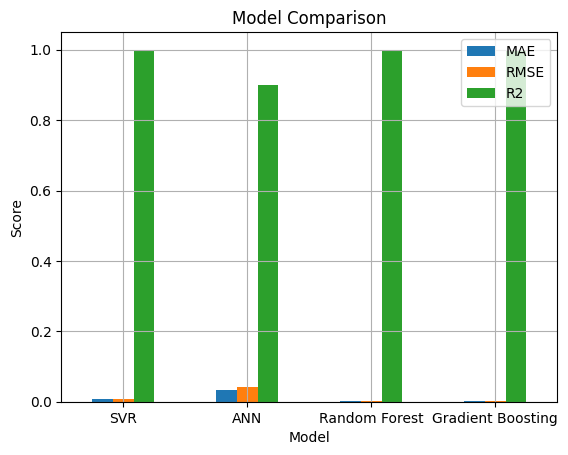

In [10]:
df_results.set_index("Model")[["MAE", "RMSE", "R2"]].plot(kind="bar")

plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.grid()

plt.show()
